In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_qcut_analysis(df, col_a, col_b, date_col=None, split_date=None, q=5, isMin =False):
    """
    根據 col_a 的分位數繪製 col_b 的平均值。
    若提供 date_col 與 split_date，則會對比分割日期前後的表現。
    """
    # 1. 準備需要用的欄位，排除 NaN
    cols_to_keep = [col_a, col_b]
    if date_col is not None:
        cols_to_keep.append(date_col)
    
    temp_df = df[cols_to_keep].dropna().copy()
    
    # 2. 進行分箱 (qcut)
    temp_df['A_bins'] = pd.qcut(temp_df[col_a], q=q, duplicates='drop')
    
    # 判斷是否要進行時間分割
    do_split = (date_col is not None) and (split_date is not None)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 內部標註數值函數
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if pd.notna(height):
                va = 'bottom' if height >= 0 else 'top'
                offset = 3 if height >= 0 else -3
                ax.annotate(f'{height:.4f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, offset),
                            textcoords="offset points",
                            ha='center', va=va, fontsize=9)

    if do_split:
        # --- 模式 A: 前後期分割對照 ---
        if not pd.api.types.is_datetime64_any_dtype(temp_df[date_col]):
            signal_df['Date'] = pd.to_datetime(signal_df['Date'])
            train_mask = temp_df[date_col] < pd.to_datetime(split_date)
        else : 
            train_mask = temp_df[date_col].astype(str).str.replace('-','').astype(int) < int(str(split_date).replace('-',''))

        mask_before = temp_df[date_col] < split_date
        mean_before = temp_df[mask_before].groupby('A_bins')[col_b].mean()
        mean_after = temp_df[~mask_before].groupby('A_bins')[col_b].mean()
        
        all_bins = mean_before.index.union(mean_after.index)
        mean_before = mean_before.reindex(all_bins)
        mean_after = mean_after.reindex(all_bins)
        
        x_labels = [f"({interval.left:.4f}, {interval.right:.4f}]" for interval in all_bins]
        x = np.arange(len(x_labels))
        width = 0.35
        
        rects1 = ax.bar(x - width/2, mean_before.values, width, 
                        label=f'Before {split_date}', color='skyblue', edgecolor='black', alpha=0.8)
        rects2 = ax.bar(x + width/2, mean_after.values, width, 
                        label=f'After {split_date}', color='salmon', edgecolor='black', alpha=0.8)
        
        autolabel(rects1)
        autolabel(rects2)
        title = f'Comparison: Mean of {col_b} by {col_a} (Split by {split_date})'
        ax.legend(fontsize=11)
        
    else:
        # --- 模式 B: 全期間單一分組 ---
        if isMin : 
            mean_total = temp_df.groupby('A_bins')[col_b].min()
        else : 
            mean_total = temp_df.groupby('A_bins')[col_b].mean()

        x_labels = [f"({interval.left:.4f}, {interval.right:.4f}]" for interval in mean_total.index]
        x = np.arange(len(x_labels))
        
        rects = ax.bar(x, mean_total.values, 0.6, color='lightgray', edgecolor='black', alpha=0.8, label='Full Period')
        
        autolabel(rects)
        if isMin : 
            title = f'Analysis: Min of {col_b} by {col_a} (Full Period)'
        else : 
            title = f'Analysis: Mean of {col_b} by {col_a} (Full Period)'

    # 圖表美化
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'{col_a} Bins', fontsize=12)
    ax.set_ylabel(f'Average {col_b}', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.axhline(0, color='gray', linewidth=1, linestyle='--')
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# --- 使用範例 ---
# 1. 只有分組繪圖 (不切日期)
# plot_qcut_analysis(df, 'Factor_A', 'Return')

# 2. 前後期對照 (切日期)
# plot_qcut_analysis(df, 'Factor_A', 'Return', date_col='Date', split_date=20240101)

In [25]:
from sdk_core import configure
from sdk_core import TwMarketData
# configure()
from src.research.negFill.rolling_model import train_and_predict_ridge_rolling

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pyarrow as pa
schema = pa.schema([
    ('price', pa.decimal128(10, 4)), 
    # 其他欄位如果沒特別指定，pyarrow 會自動推斷
])

from backTest import BackTest
from factorAnalyzer import FactorAnalyzer_Polars


In [3]:

folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[-5:])

['20260326.parquet' '20260327.parquet' '20260330.parquet'
 '20260331.parquet' '20260401.parquet']


In [4]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[1:]): 
    targetLabel = 'BidPrice1' 
    rankThres_btn = 0
    rankThres = 150
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x[targetLabel] * x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = ((stock_df['BidPrice1'] - stock_df.RefPrice) / stock_df.RefPrice ).round(4)
        # stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        # stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.FutureHigh) / stock_df[targetLabel] * 10000)
        stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.08 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.RefPrice*1.08 - stock_df.TickSize*2) / stock_df[targetLabel] * 10000)
        PriceCondition = (stock_df.ToRef > -0.02) & (stock_df.ToRef < 0.05)
        # seqCondition = (stock_df.BidPrice1.diff()!= 0)
        AmountCondition = (stock_df.day_amount_rank <= rankThres) | (stock_df.AmountRank_canDayTrade <= rankThres) 
        # AmountCondition2 = (stock_df.day_amount_rank > rankThres_btn) & (stock_df.AmountRank > rankThres_btn)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
        # break       
    # if f.split('.')[0] == '20260309':
    #     break

100%|██████████| 778/778 [00:38<00:00, 20.35it/s]


In [5]:
signal_df = pd.concat(data).reset_index(drop=True)

In [6]:
priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]
signal_df[:][priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']].head(10)

,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2023-01-05 09:00:21.022822,1101,100950,597,34.20,1,34.25,20,34.20,34.7,33.5,34.45,34.15,1.0,-73.099415,0.0209,-415,122.0,NaN,None,NaT
1,2023-01-05 09:00:26.569747,1101,107081,704,34.25,1,34.30,59,34.25,34.7,33.5,34.45,34.15,1.0,-58.394161,0.0224,-472,122.0,NaN,None,NaT
2,2023-01-05 09:00:26.809839,1101,107272,714,34.20,163,34.30,60,34.25,34.7,33.5,34.45,34.15,2.0,-73.099415,0.0209,-482,122.0,NaN,None,NaT
3,2023-01-05 09:00:27.384746,1101,107773,751,34.25,1,34.30,31,34.30,34.7,33.5,34.45,34.15,1.0,-58.394161,0.0224,-445,122.0,NaN,None,NaT
4,2023-01-05 09:00:28.077559,1101,108496,755,34.25,1,34.30,30,34.30,34.7,33.5,34.45,34.15,1.0,-58.394161,0.0224,-443,122.0,NaN,None,NaT
5,2023-01-05 09:00:31.873504,1101,112210,791,34.25,143,34.35,52,34.30,34.7,33.5,34.45,34.15,2.0,-58.394161,0.0224,-417,122.0,NaN,None,NaT
6,2023-01-05 09:00:33.085004,1101,113530,795,34.30,1,34.35,54,34.30,34.7,33.5,34.45,34.15,1.0,-43.731778,0.0239,-413,122.0,NaN,None,NaT
7,2023-01-05 09:00:56.034479,1101,136372,1154,34.35,6,34.45,74,34.40,34.7,33.5,34.45,34.15,2.0,-29.112082,0.0254,-246,122.0,NaN,None,NaT
8,2023-01-05 09:00:56.062957,1101,136402,1160,34.30,76,34.45,74,34.40,34.7,33.5,34.45,34.15,3.0,-43.731778,0.0239,-252,122.0,NaN,None,NaT
9,2023-01-05 09:00:56.184426,1101,136512,1160,34.35,6,34.45,72,34.40,34.7,33.5,34.45,34.15,2.0,-29.112082,0.0254,-252,122.0,NaN,None,NaT


In [7]:
# target_time_str = "13:25:00"
# target_dt = pd.to_datetime(signal_df['TransTime'].dt.date.astype(str) + " " + target_time_str)
# signal_df['RemainSeconds'] = (target_dt - signal_df['TransTime']).dt.total_seconds()
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) & (signal_df.TransTime.dt.time > datetime.time(9, 0, 30)) & (signal_df.TrialMatch == 0)].reset_index(drop=True)
# signal_df = signal_df[  ((signal_df.Date.astype(int) - 20260220).abs() > 5 )& (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
signal_df = signal_df[  (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
# signal_df = signal_df[  (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
signal_df['midEdge_300sBP'] = signal_df['midEdge_300sBP']*-1

In [8]:
signal_df.head(1)

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date
0,2023-01-05 09:00:31.873504,2023-01-05 09:00:31.873504,1101,1101,784333,112210,0,0,-1,1,791,34.25,34.2,34.15,34.1,34.05,143,179,118,51,51,34.35,34.4,34.45,34.5,34.55,52,73,25,248,20,34.25,2,0.0,0,0.0,0,"{""p"":343000,""l"":1}",2,33.5,False,True,34.15,34.45,34.3,34.15,34.7,34.05,0.004478,0.0,1.0,-0.05,0.0,0.05,14.59854,34.3,0.0224,0.004392,-417,58,-417,0.733333,0.263838,0.594096,0.124402,0.299043,2.0,3,34.35,34.25,1,NaN,0.0,0.078517,-1.0,2,87,3,15868,34.35,34.3,34.4,34.35,34.4,34.35,34.3,34.25,34.15,34.1,34.25,34.2,-58.394161,29.112082,7.28863,21.865889,21.865889,-7.28863,51.020408,-21.865889,X,10493097.0,182243.0,592000.0,0.0,-3074323.0,27000.0,284.0,-3.0,X,10413.0,3509.0,3046.0,180.302706,242.571005,2254.0,-0.002234,20.0,-30.012817,3.92992,20.0,18.878836,11.791032,0.036689,-44.565533,-9.29368,29.761905,14.869888,0.193744,-29.761905,0.0,29.761905,29.739777,29.806259,-42.906032,-6.606401,19.135821,-2.127443,-1.653713,-0.998408,17.440131,16.970892,-34.880893,-54.362801,-29.761905,-34.442624,122.0,53.0,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20230105


<Axes: xlabel='Date'>

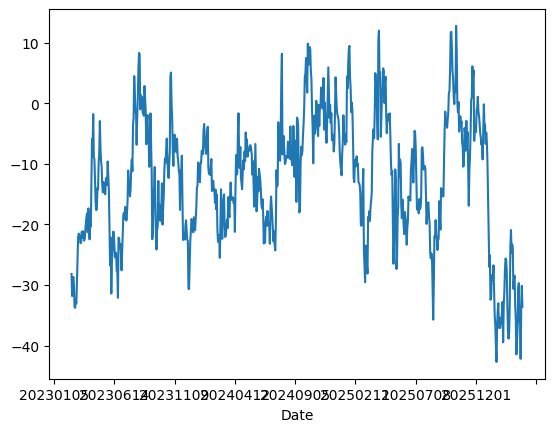

In [9]:
signal_df[:].groupby(['Date','QuoteCode']).TakerSell_CloseBP.mean().reset_index().groupby(['Date']).TakerSell_CloseBP.mean().rolling(30).mean().plot()

In [10]:
signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date','QuoteCode']).TakerSell_CloseBP.transform('mean')
# signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby(['Date']).TakerSell_CloseBP.transform('mean')

In [11]:
signal_df.TakerSell_CloseBP.describe()

count    1.579629e+07
mean     3.875027e+01
std      2.552160e+02
min     -1.116000e+03
25%     -7.843137e+01
50%      4.184100e+01
75%      1.748252e+02
max      1.423877e+03
Name: TakerSell_CloseBP, dtype: float64

In [12]:
signal_df.TakerSell_CloseBP_net.describe()

count    1.579629e+07
mean     3.132160e-17
std      8.966496e+01
min     -1.391685e+03
25%     -4.387218e+01
50%     -1.086265e+00
75%      4.406673e+01
max      1.379359e+03
Name: TakerSell_CloseBP_net, dtype: float64

In [ ]:
import pandas as pd
import json

# 1. 讀取 JSON 檔案還原成 list
with open('abnormal_dates.json', 'r') as f:
    loaded_date_list = json.load(f)

signal_df['isAbnormalDate'] = signal_df['Date'].isin(loaded_date_list) *1

signal_df.head()

In [13]:
based_columns = ['QuoteCode', 'ChannelSeq', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1','BidLots1', 'BidLots5', 'AskPrice1', 'AskLots1', 'AskLots5', 'FillLots']
feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'ToRef', 'ToOpen', 'FillLots_atLow', 'FillLots_atHigh', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'SpreadPairID', 'SpreadPairSeq', 'SpreadPairElapsed', 'SpreadNarrowSide', 'SpreadPairCumLots', 'PrevSpreadPairLots', 'RemainSeconds']
cross_columns = ['AmountRank', 'netAmountRank', 'TotalFillLotsRank', 'netTotalFillLotsRank', 'ToRefRank']
day_columns = ['dealer_hedging_netLots', 'dealer_netLots', 'foreign_dealer_netLots', 'foreign_netLots', 'investment_netLots', 'margin_netLots', 'short_netLots', 'nextday_allow_day_trade_mark', 'trading_volume_noOdd', 'big_buy_lots', 'big_buy_ToCloseBP', 'big_buy_300sBP', 'big_sell_lots', 'big_sell_ToCloseBP', 'big_sell_300sBP', 'hft_participation', 'hft_buy_ToCloseBP', 'hft_buy_300sBP', 'hft_sell_ToCloseBP', 'hft_sell_300sBP', 'day_amount_rank', 'day_lots_rank']
# # 
feature = based_columns + feature_columns + cross_columns + day_columns


# ================= [新增] 1. 執行 Lookback Rank 轉換 =================
import pandas as pd
from src.research.negFill.rolling_model import train_and_predict_ridge_rolling

# 🌟 殺手鐧：直接在 Pandas 階段把字串強制轉成 Datetime！🌟
# # 這樣傳進 Polars 時就絕對不會是字串了
signal_df['Date'] = pd.to_datetime(signal_df['Date'])

# 接著再轉成 Polars
signal_df_pl = pl.from_pandas(signal_df)

# 因為我們改用 importlib 強制重載，確保一定抓到最新版
import importlib
import feature_transforms
importlib.reload(feature_transforms)
apply_lookback_rank = feature_transforms.apply_lookback_rank  # 重新綁定函數

# 執行 Rank 轉換
signal_df_pl, rank_features = apply_lookback_rank(
    df=signal_df_pl, 
    time_col='Date', 
    feature_cols=feature, 
    n_days=5
)

# 轉回 Pandas 以相容你後續的流程
signal_df = signal_df_pl.to_pandas()


In [15]:

# 把原始特徵跟新算出來的 Rank 特徵合併，餵給 Analyzer
# all_features_to_test = original_features + rank_features

# ================= 2. 核心分析迴圈 =================
for label in ['TakerSell_CloseBP_net', 'TakerSell_CloseBP']: 
    analyzer = FactorAnalyzer_Polars(signal_df[signal_df.Date.astype(int)>20251201], label_col=label, feature_cols=feature, time_col='Date', weight_col='BidPrice1')
    
    # --- A. 靜態全域特徵篩選 (原本的邏輯) ---
    top_factors_df = analyzer.screen_single_factors(split_date='2026-03-01', n_quantiles=5, spread_threshold=40.0)
    
    # 這裡因為你原版的 _calc_ic_spread 回傳的 dict key 是 IC_Drop，如果你的 DataFrame 真的叫 Stability，請依你實際的欄位名稱為主
    condition_sample = (top_factors_df.get('Stability', top_factors_df.get('IC_Drop', 0)) > 0.5) & (top_factors_df.IS_Spread * top_factors_df.IS_IC.apply(np.sign) > 40 )
    
    # (註：如果你的版本沒有 W_Stability，這行可能會報錯，請確認你原本的 top_factors_df 欄位)
    # condition_weight = (top_factors_df.W_Stability > 0.5) & (top_factors_df.IS_W_Spd * top_factors_df.IS_W_IC.apply(np.sign) > 40 )
    
    static_top_factors = top_factors_df[ condition_sample ].Feature.to_list()
    
    # --- B. [新增] 動態長短期特徵篩選 ---
    # 輸出 DataFrame 包含每日的 'Short_Term_Only', 'Long_Term_Only', 'Robust_Features', 'Selected_Features'
    term_structure_df = analyzer.get_term_structure_features(short_window=5, long_window=20, ic_threshold=0.02)
    
    # 你可以把每日動態選出的特徵跟靜態特徵結合，餵給你的模型
    # print(term_structure_df.tail(3))
    
    break
    # signal_df = train_and_predict_ridge(signal_df, static_top_factors, label, train_date='2025-01-01')

>>> 初始化資料並轉換為 Polars 極速引擎...
✅ Polars 引擎準備完畢！資料筆數: 2,145,156 筆 | 有效特徵數: 59

🚀 開始單一因子全局海選 (靜態上帝視角)
⏱️ 樣本切割點: 2026-03-01 | 🎯 過濾條件: |Spread| > 40.0


⚙️ 因子運算進度:  67%|██████▋   | 39/58 [00:06<00:03,  6.22it/s]/home/kevin/Project/HFT/src/research/factorAnalyzer.py:82: RuntimeWarning: invalid value encountered in scalar divide
  w_ic = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
⚙️ 因子運算進度: 100%|██████████| 58/58 [00:09<00:00,  6.14it/s]



✅ 篩選完成！共找到 12 個 Spread > 40.0 的強勢因子。


🗓️ 啟動長短期特徵動態篩選 | 短期: 5天 | 長期: 20天 | 門檻: |IC|>=0.02
✅ 雙視窗篩選完成！產出 72 天的特徵清單。


import pandas as pd
from sklearn.linear_model import Ridge

def train_and_predict_ridge(signal_df, X_list, Y_col):
    print(f"🔍 目前預測目標: {Y_col}")
    
    # 計算 0.1% 的閾值 (threshold)
    total_rows = len(signal_df)
    threshold = total_rows * 0.01
    print(f"📊 資料總筆數: {total_rows} | 0.1% 容忍閾值: {threshold:.2f} 筆")
    
    # 建立分類清單
    cols_to_drop_rows = []
    cols_to_remove_from_X = []
    
    # ==========================================
    # 1. 檢查 X_list 裡面的 NaN 狀況並分類
    # ==========================================
    for col in X_list:
        nan_count = signal_df[col].isna().sum()
        if nan_count > 0:
            if nan_count < threshold:
                # NaN 數量小於 0.1%，標記為準備 dropna (刪除資料列)
                cols_to_drop_rows.append(col)
            else:
                # NaN 數量大於等於 0.1%，標記為準備移除特徵
                cols_to_remove_from_X.append(col)
                
    # ==========================================
    # 2. 執行移除特徵 (Columns) 動作
    # ==========================================
    # 產生真正要進模型的 current_X
    current_X = [col for col in X_list if col not in cols_to_remove_from_X]
    
    if cols_to_remove_from_X:
        print(f"⚠️ 以下特徵 NaN 數量超過閾值，已從 X_list 中移除：")
        for col in cols_to_remove_from_X:
            nan_count = signal_df[col].isna().sum()
            print(f"   - {col} (NaN: {nan_count} 筆)")
            
    # ==========================================
    # 3. 處理 Y 的 NaN 與執行 dropna (刪除資料列)
    # ==========================================
    # 確保 Y 如果有 NaN 也一併剔除該筆資料
    signal_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    if signal_df[Y_col].isna().sum() > 0 and Y_col not in cols_to_drop_rows:
        cols_to_drop_rows.append(Y_col)
        
    if cols_to_drop_rows:
        print(f"🧹 以下欄位 NaN 數量極少 (低於閾值)，將直接剔除帶有 NaN 的資料列：")
        for col in cols_to_drop_rows:
            nan_count = signal_df[col].isna().sum()
            print(f"   - {col} (NaN: {nan_count} 筆)")
            
        # 實際執行 dropna，並更新 signal_df
        signal_df = signal_df.dropna(subset=cols_to_drop_rows).copy()
        print(f"✅ 剔除後剩餘資料總筆數: {len(signal_df)}")
        
    # ==========================================
    # 4. 顯示最終要進模型的 X_list
    # ==========================================
    print("-" * 40)
    print(f"🚀 最終使用的 X_list (共 {len(current_X)} 個特徵):")
    print(current_X)
    print("-" * 40)
    
    # 安全機制：如果所有 X 都被砍光了，就拋出錯誤
    if not current_X:
        raise ValueError("所有的 X 特徵都因為 NaN 太多被移除了，無法建立模型！")

    # ==========================================
    # 5. 處理時間與切分訓練集
    # ==========================================
    if not pd.api.types.is_datetime64_any_dtype(signal_df['Date']):
        signal_df['Date'] = pd.to_datetime(signal_df['Date'])
        
    train_mask = (signal_df['Date'] >= pd.to_datetime('2025-11-01')) & (signal_df['Date'] <= pd.to_datetime('2026-02-13'))
    lot_mask = signal_df.groupby(['Date','QuoteCode']).BidPrice1.cumsum()/10 < 500 
    date_mask = (signal_df.isAbnormalDate == 0)
    train_df = signal_df[train_mask & lot_mask & date_mask]
    
    # ==========================================
    # 6. 建立並訓練 Ridge 模型
    # ==========================================
    model = Ridge(alpha=10.0)
    model.fit(train_df[current_X], train_df[Y_col])
    
    # ==========================================
    # 7. 對整份 signal_df 進行預測
    # ==========================================
    pred_col_name = f"{Y_col}_pred"
    signal_df[pred_col_name] = model.predict(signal_df[current_X])


    date_mask = (signal_df.isAbnormalDate == 1)
    train_df = signal_df[train_mask & lot_mask & date_mask]
    
    # ==========================================
    # 6. 建立並訓練 Ridge 模型
    # ==========================================
    model = Ridge(alpha=10.0)
    model.fit(train_df[current_X], train_df[Y_col])
    
    # ==========================================
    # 7. 對整份 signal_df 進行預測
    # ==========================================
    pred_col_name = f"{Y_col}_ABpred"
    signal_df[pred_col_name] = model.predict(signal_df[current_X])
    
    return signal_df

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date,TakerSell_CloseBP_net,isAbnormalDate
0,2023-01-05 09:00:31.873504,2023-01-05 09:00:31.873504,1101,1101,784333,112210,0,0,-1,1,791,34.25,34.20,34.15,34.10,34.05,143,179,118,51,51,34.35,34.4,34.45,34.5,34.55,52,73,25,248,20,34.25,2,0.0,0,0.0,0,"{""p"":343000,""l"":1}",2,33.5,False,True,34.15,34.45,34.3,34.15,34.7,34.05,0.004478,0.000000,1.0,-0.05,0.0,0.05,14.598540,34.300,0.0224,0.004392,-417,58,-417,0.733333,0.263838,0.594096,0.124402,0.299043,2.0,3,34.35,34.25,1,NaN,0.000000,0.078517,-1.0,2,87,3,15868,34.35,34.30,34.40,34.35,34.40,34.35,34.3,34.25,34.15,34.1,34.25,34.2,-58.394161,29.112082,7.288630,21.865889,21.865889,-7.288630,51.020408,-21.865889,X,10493097.0,182243.0,592000.0,0.0,-3074323.0,27000.0,284.0,-3.0,X,10413.0,3509.0,3046.0,180.302706,242.571005,2254.0,-0.002234,20.0,-30.012817,3.92992,20.0,18.878836,11.791032,0.036689,-44.565533,-9.29368,29.761905,14.869888,0.193744,-29.761905,0.0,29.761905,29.739777,29.806259,-42.906032,-6.606401,19.135821,-2.127443,-1.653713,-0.998408,17.440131,16.970892,-34.880893,-54.362801,-29.761905,-34.442624,122.0,53.0,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20230105,0.079017,0
1,2023-01-05 09:00:33.085004,2023-01-05 09:00:33.085004,1101,1101,785653,113530,0,0,0,0,795,34.30,34.25,34.20,34.15,34.10,1,163,185,114,51,34.35,34.4,34.45,34.5,34.55,54,73,25,248,20,0.00,0,0.0,0,0.0,0,NaN,0,33.5,False,True,34.15,34.45,34.3,34.15,34.7,34.05,0.004478,0.000000,1.0,0.05,0.0,0.05,14.577259,34.325,0.0239,0.005124,-413,62,-413,0.018182,0.001946,0.319066,0.128571,0.302381,1.0,3,34.35,34.25,1,1.0,0.081716,0.081716,1.0,6,87,3,15866,34.35,34.30,34.40,34.35,34.40,34.35,34.3,34.25,34.15

In [22]:
top_factors = top_factors_df.Feature.to_list() #['ToRef', 'ToRefRank', 'ToOpen', 'Low_High', 'ToLow','ToHigh' ,'TickBP','netTotalFillLotsRank']
label = 'TakerSell_CloseBP_net'

In [23]:
for c in top_factors : 
    daily_median = signal_df.groupby('Date')[c].median()
    shifted_daily_median = daily_median.shift(1)
    signal_df[c] = signal_df[c].fillna(signal_df['Date'].map(shifted_daily_median))
    # signal_df[c] = signal_df[c].fillna(0)

# signal_df['ToRefRank'] = signal_df['ToRefRank'].fillna(signal_df.ToRefRank.median())
# signal_df['netTotalFillLotsRank'] = signal_df['netTotalFillLotsRank'].fillna(signal_df.netTotalFillLotsRank.median())
# signal_df['ToOpenRank'] = signal_df['ToOpenRank'].fillna(signal_df.ToOpenRank.median())
# signal_df['big_buy_ToCloseBP'] = signal_df['big_buy_ToCloseBP'].fillna(signal_df.big_buy_ToCloseBP.median())
# signal_df['big_sell_ToCloseBP'] = signal_df['big_sell_ToCloseBP'].fillna(signal_df.ToOpenRank.median())

In [26]:
signal_df = train_and_predict_ridge_rolling(signal_df, top_factors, label, n_training_days=60)

🔍 目前預測目標: TakerSell_CloseBP_net | Rolling Training 視窗: 60 天
🔄 為了 O(1) NumPy 加速，強制將資料依照 Date 進行排序...
📊 資料總筆數: 15796291 | 0.1% 容忍閾值: 157962.91 筆
🧹 以下欄位 NaN 數量極少 (低於閾值)，將直接剔除帶有 NaN 的資料列：
   - ToRefRank (NaN: 3103 筆)
   - netAmountRank (NaN: 3103 筆)
   - netTotalFillLotsRank (NaN: 3103 筆)
✅ 剔除後剩餘資料總筆數: 15793188
----------------------------------------
🚀 最終使用的 X_list (共 12 個特徵):
['ToRef', 'Low_High', 'ToRefRank', 'ToHigh', 'ToOpen', 'ToLow', 'netAmountRank', 'RemainSeconds', 'netTotalFillLotsRank', 'FillLots_atHigh', 'ChannelSeq', 'SpreadPairID']
----------------------------------------
🔍 檢查是否有「全段期間皆為常數」(Zero Variance) 的特徵...
🔄 計算 Lot Mask (BidPrice1 cumsum) 與準備 NumPy 陣列
▶️ 開始對 778 個交易日進行 純Numpy極速 平行 Rolling Update (Core 數: -1)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 584 tasks      | elapsed:    7.1s


✅ 平行 Rolling 更新預測完成！


[Parallel(n_jobs=-1)]: Done 778 out of 778 | elapsed:    8.8s finished


signal_df = train_and_predict_ridge(signal_df, top_factors, label).reset_index(drop=True)
# signal_df['Date'] = signal_df['Date'].dt.strftime('%Y%m%d')

In [27]:
signal_df.head(2)

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date,TakerSell_CloseBP_net,isAbnormalDate,TakerSell_CloseBP_net_pred,TakerSell_CloseBP_net_ABpred
0,2023-01-05 11:54:49.904915,2023-01-05 11:54:49.904915,5274,5274,13316782,1168808,0,0,-1,0,366,1770.0,1765.0,1760.0,1755.0,1750.0,4,7,10,14,14,1780.0,1785.0,1790.0,1795.0,1800.0,4,11,4,6,12,1775.0,1,0.0,0,0.0,0,NaN,1,1765.0,True,True,1790.0,1765.0,1815.0,1750.0,1805.0,1765.0,0.014164,0.022663,0.384615,-5.0,0.0,5.0,28.248588,1775.0,0.0028,-0.00838,-5,-65,-52,0.500000,0.081633,0.22449,0.108108,0.405405,2.0,15,1780.0,1770.0,5,NaN,0.0,391.452976,-1.0,15,36,56,5410,1780.0,1770.0,1780.0,1770.0,1780.0,1770.0,1780.0,1770.0,1780.0,1770.0,1780.0,1770.0,28.248588,-84.269663,0.0,0.000000,0.000000,0.000000,-0.000000,0.000000,X,277000.0,1000.0,-925.0,0.0,80.0,-20000.0,-9.0,-13.0,X,277.0,-33.0,-46.0,2.828289,3.791036,36.0,-0.005666,2.0,-50.454781,15.208944,3.0,-20.595291,12.251167,0.020668,-28.409091,28.449502,-14.285714,-7.112376,0.026648,NaN,NaN,-14.285714,-7.112376,14.245014,-13.051501,1.221108,-48.273373,-16.702844,22.844089,-0.993458,-153.577165,-28.931793,-58.275414,-55.988341,64.191856,79.607796,86.0,687.0,2023-01-05 11:47:56.695220,11:50:00,59.0,1754.0,544.0,1349.0,232.0,1078.0,95.0,446.0,402.0,214.0,59.0,2023-01-05,13.283047,0,NaN,NaN
1,2023-01-05 11:22:45.194654,2023-01-05 11:22:45.194654,5274,5274,12618738,1027939,0,0,-1,0,334,1770.0,1765.0,1760.0,1755.0,1750.0,3,8,10,14,15,1780.0,1785.0,1790.0,1795.0,1800.0,8,12,6,8,12,1775.0,1,0.0,0,0.0,0,NaN,1,1765.0,True,True,1790.0,1765.0,1815.0,1750.0,1805.0,1765.0,0.014164,0.022663,0.384615,-5.0,0.0,5.0,28.248588,1775.0,0.0028,-0.00838,-1,-61,-48,0.272727,0.060000,0.22000,0.173913,0.434

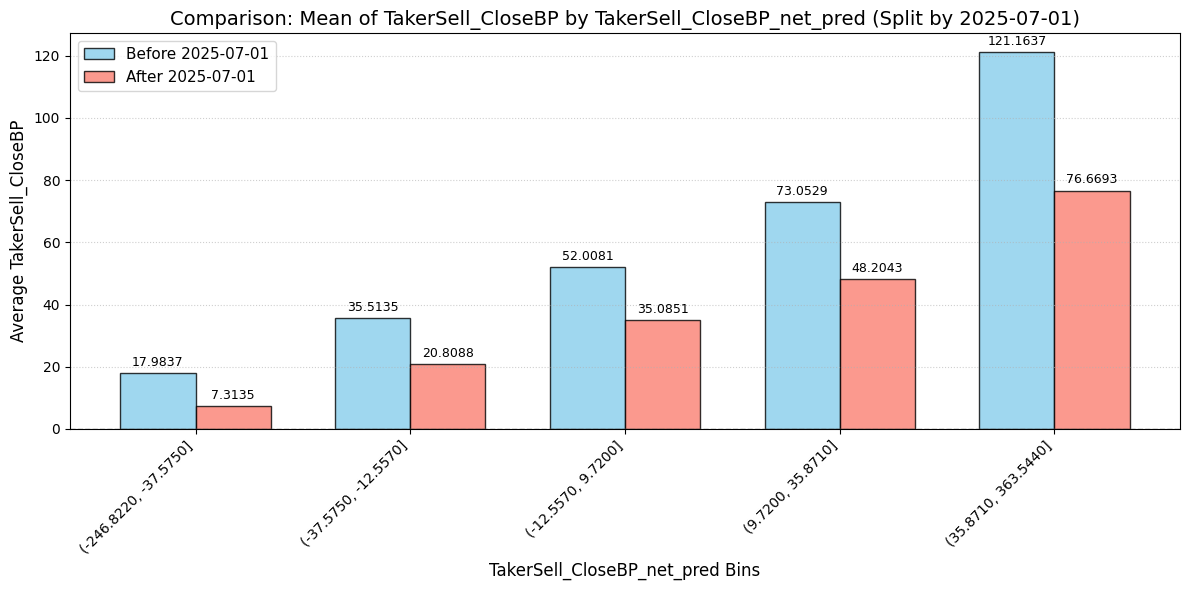

In [28]:
plot_qcut_analysis(signal_df[signal_df.isAbnormalDate == 0], 'TakerSell_CloseBP_net_pred', 'TakerSell_CloseBP', date_col='Date', split_date='2025-07-01')


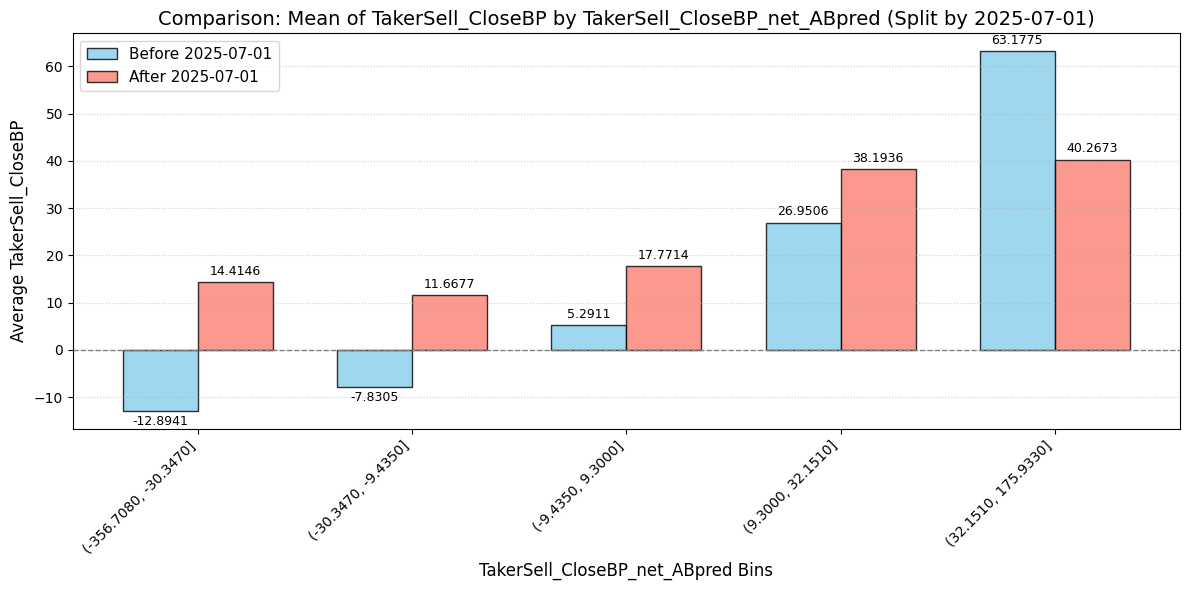

In [29]:
plot_qcut_analysis(signal_df[signal_df.isAbnormalDate == 1], 'TakerSell_CloseBP_net_ABpred', 'TakerSell_CloseBP', date_col='Date', split_date='2025-07-01')


In [30]:
condition = pd.Series( [True for i in range(len(signal_df))] )
# condition =   (signal_df.ToOpen <0)# (signal_df.Position<200) #(signal_df.big_sell_ToCloseBP > 20 ) & (signal_df.InOut < 0 ) & (signal_df.FillLots > signal_df.big_sell_lots)
# condition = condition | ((signal_df.Spread <= 1 ) & ((signal_df.SpreadPairSeq>5) & (signal_df.SpreadPairID > 5)))
condition = condition & (( signal_df.TakerSell_CloseBP_net_pred * (signal_df.isAbnormalDate == 0 ) > 40) | ( signal_df.TakerSell_CloseBP_net_ABpred * (signal_df.isAbnormalDate == 1 ) > 40)) #&(signal_df.SpreadCountAtSameCount <= 1)#& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
print( signal_df[condition].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round((signal_df[condition].TakerSell_CloseBP * signal_df[condition].BidPrice1).sum() / signal_df[condition].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

condition_recent = condition & (signal_df.Date.dt.strftime('%Y%m%d').astype(int) > 20260101) #& (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )
print( signal_df[condition_recent].TakerSell_CloseBP.describe() ) 
print('')
print( 'cap BP : '+str( round((signal_df[condition_recent].TakerSell_CloseBP * signal_df[condition_recent].BidPrice1).sum() / signal_df[condition_recent].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition_recent].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

count    2.579064e+06
mean     9.181527e+01
std      3.203562e+02
min     -1.076221e+03
25%     -7.142857e+01
50%      1.379310e+02
75%      3.040000e+02
max      1.423877e+03
Name: TakerSell_CloseBP, dtype: float64

cap BP : 59.86
averge prod num : 79.97
count    333996.000000
mean         17.489567
std         397.929389
min       -1076.221498
25%        -333.164557
50%          28.694405
75%         286.975717
max        1412.133891
Name: TakerSell_CloseBP, dtype: float64

cap BP : -56.95
averge prod num : 78.46


In [31]:
signal_df = signal_df[condition].reset_index(drop=True)
# signal_df = signal_df[condition & ((signal_df.Date.astype(int) < 20260101) |( (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )))].reset_index(drop=True)


In [49]:
signal_df.head()

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,FillLots_origin,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,BidPreMove,AskPreMove,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadCountAtSameCount,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,SpreadPairTotalCount,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,hft_strick_participation,hft_strick_buy_ToCloseBP,hft_strick_buy_300sBP,hft_strick_sell_ToCloseBP,hft_strick_sell_300sBP,hft_strick_makerSpreadBP,firstMaker_buy_ToCloseBP,firstMaker_buy_300sBP,firstMaker_sell_ToCloseBP,firstMaker_sell_300sBP,firstMaker_makerSpreadBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,AmountRank_canDayTrade,Date,TakerSell_CloseBP_net,isAbnormalDate,TakerSell_CloseBP_net_pred,TakerSell_CloseBP_net_ABpred,PosLots,Position
0,2023-01-09 09:14:12.425824,2023-01-09 09:14:12.425824,6531,6531,1521603,862382,0,0,-1,0,767,185.5,185.0,184.5,184.0,183.5,35,70,49,56,56,186.5,187.0,187.5,188.0,188.5,22,47,40,70,21,186.0,1,0.0,0,0.0,0,NaN,1,182.0,False,True,186.0,186.5,187.5,185.0,189.5,185.5,0.005495,0.008242,0.4,-0.5,0.0,0.5,26.954178,186.00,0.0192,0.000000,-19,-179,-57,0.614035,0.131579,0.394737,0.110000,0.345000,2.0,1,186.5,185.5,5,67.0,0.000000,0.040979,-1.0,272,129,12,15047,186.5,185.5,186.0,185.5,186.0,185.5,186.0,185.5,186.5,186.0,187.0,186.5,-53.908356,0.000000,0.000000,-13.440860,-13.440860,-13.440860,-13.440860,40.322581,X,2897042.0,166268.0,5000.0,0.0,365000.0,0.0,26.0,32.0,X,2881.0,575.0,-87.0,13.426116,23.191044,165.0,-0.001372,8.0,117.353240,19.949945,5.0,-97.676661,11.436703,0.184908,199.465087,32.814131,-117.876230,-6.115380,0.242713,219.924236,33.787814,-111.111111,27.739251,-84.459459,83.194477,-4.490433,-176.259060,-21.041315,-128.809564,-0.999882,-409.933142,-80.864111,88.326290,77.074614,NaN,369.251692,85.0,185.0,2023-01-09 09:09:59.756328,09:10:00,73.0,1663.0,163.0,1496.0,72.0,654.0,36.0,337.0,389.0,250.0,73.0,2023-01-09,-63.753255,0,53.483065,16.787258,1,18.55
1,2023-01-09 09:00:58.781067,2023-01-09 09:00:58.781067,6491,6491,813029,154134,0,0,0,0,7,417.5,417.0,416.0,415.5,415.0,4,7,5,1,1,418.5,419.0,420.0,420.5,421.0,1,1,5,2,5,0.0,0,0.0,0,0.0,0,NaN,0,411.5,False,True,416.5,425.5,417.5,416.5,426.0,411.0,0.002430,0.000000,1.0,0.5,0.0,0.5,11.976048,418.00,0.0146,0.003601,-5,1,-5,0.800000,0.222222,0.611111,0.071429,0.

In [ ]:
## 部位留存
signal_df['PosLots'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumcount') + 1
signal_df['Position'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumsum') / 10
# signalwithRisk_df = signal_df[ (~((signal_df.PosLots >1) & (signal_df.Position >= 10))) & (signal_df.BidPrice1<=100)].reset_index(drop=True)
signalwithRisk_df = signal_df[  (~((signal_df.PosLots >1) & (signal_df.Position > 200))) & (signal_df.BidPrice1<1000)  ].reset_index(drop=True)
# signalwithRisk_df = signal_df[ (signal_df.PosLots ==1) & (signal_df.BidPrice1 <= 100)].reset_index(drop=True)


for d in signalwithRisk_df[lambda x : x.Date.astype(int) > 20260319].Date.unique() :
    signalwithRisk_df[lambda x : x.Date == d].reset_index(drop=True).to_csv(f'{d}_10w.csv')

In [ ]:
# signalwithRisk_df['totalPosition'] = signalwithRisk_df.groupby(['Date']).BidPrice1.transform('cumsum') / 10

# signalwithRisk_df = signalwithRisk_df[ (signalwithRisk_df.totalPosition <= 10000 )].reset_index(drop=True)

In [125]:
signalwithRisk_df['Date'] = signalwithRisk_df.Date.dt.strftime('%Y%m%d')

signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ].QuoteCode.unique()

<ArrowStringArray>
['6127', '5871', '4989', '5291', '4967', '4958', '4931', '5483', '5439',
 '5347', '4906', '4919', '8021', '6770', '8096', '8028', '8039', '6415',
 '6257', '6239', '6213', '6285', '6414', '6290', '6443', '2344', '2367',
 '2356', '2049', '2303', '2317', '2324', '2301', '2481', '2408', '2409',
 '2382', '2449', '2458', '1785', '1513', '1303', '1815', '1802', '2002',
 '2027', '3702', '3376', '3305', '3481', '3450', '3715', '3706', '3030',
 '2885', '2886', '2887', '3026', '3023', '2891', '3005', '3036', '2489',
 '2603', '2882', '2881', '3265', '3264', '3231']
Length: 69, dtype: str

In [126]:
signalwithRisk_df[ (signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max()) & (signalwithRisk_df.FutureHigh > signalwithRisk_df.RefPrice *1.09) ].QuoteCode.unique()

<ArrowStringArray>
['4906', '6213', '2409', '1303', '2489']
Length: 5, dtype: str

In [127]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()
position = (signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum()

rank_series = series1.rank(pct=True)

dateSeq = -1

# 取得最後一天的排名
latest_date = series1.index[dateSeq]
latest_rank = rank_series.iloc[dateSeq]

print(f"日期: {latest_date}")
print(f"單邊部位: {position.iloc[dateSeq]:.2f} 萬")
print(f"損益: {series1.iloc[dateSeq]:.2f} 萬")

rank_series = series1.rank()
latest_rank2 = rank_series.iloc[dateSeq]
print(f"排名: {latest_rank2},  {latest_rank :.2%}") # 例如 85.00%，代表贏過歷史 85% 的天數




日期: 20260401
單邊部位: 9215.52 萬
損益: -13.71 萬
排名: 164.0,  21.13%


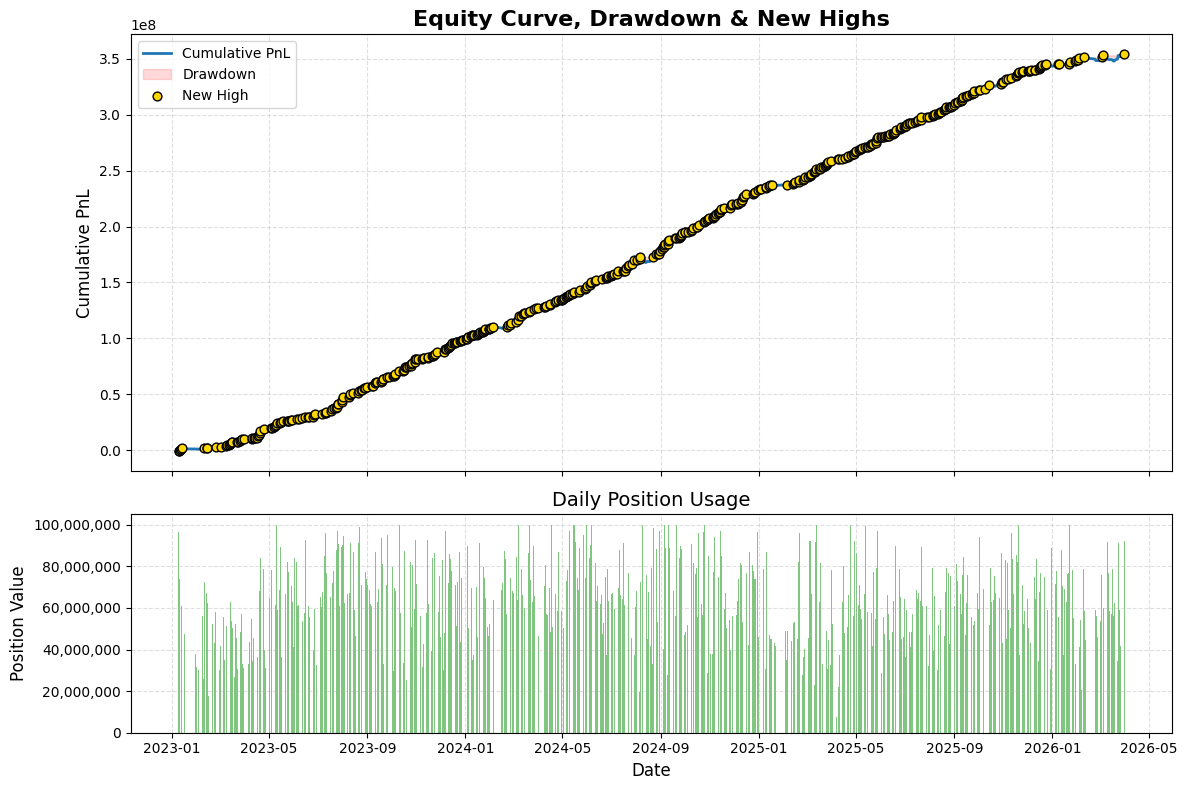


指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 35,393.84
近一年報酬（萬）      : 9,701.48
風報比                  : 68.80
年化 Sharpe          : 9.01
創高最長費時 (天)     : 17
平均每日交易商品數   : 57.20

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 167.82%
近一年報酬率（近一年平均部位）: 153.23%
勝率 (日/單筆)      : 70.75% / 66.42%
平均BP (單/單位)   : 70.85 / 69.9270

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -449.08 萬
MDD金額/佔平均比   : -514.44 萬 / 7.89%
平均/最大部位(萬)  : 6,522.61 / 9,999.97
平均最大單一商品比  : 3.45%



In [128]:
bt = BackTest(signalwithRisk_df)
results = bt.run_analysis()

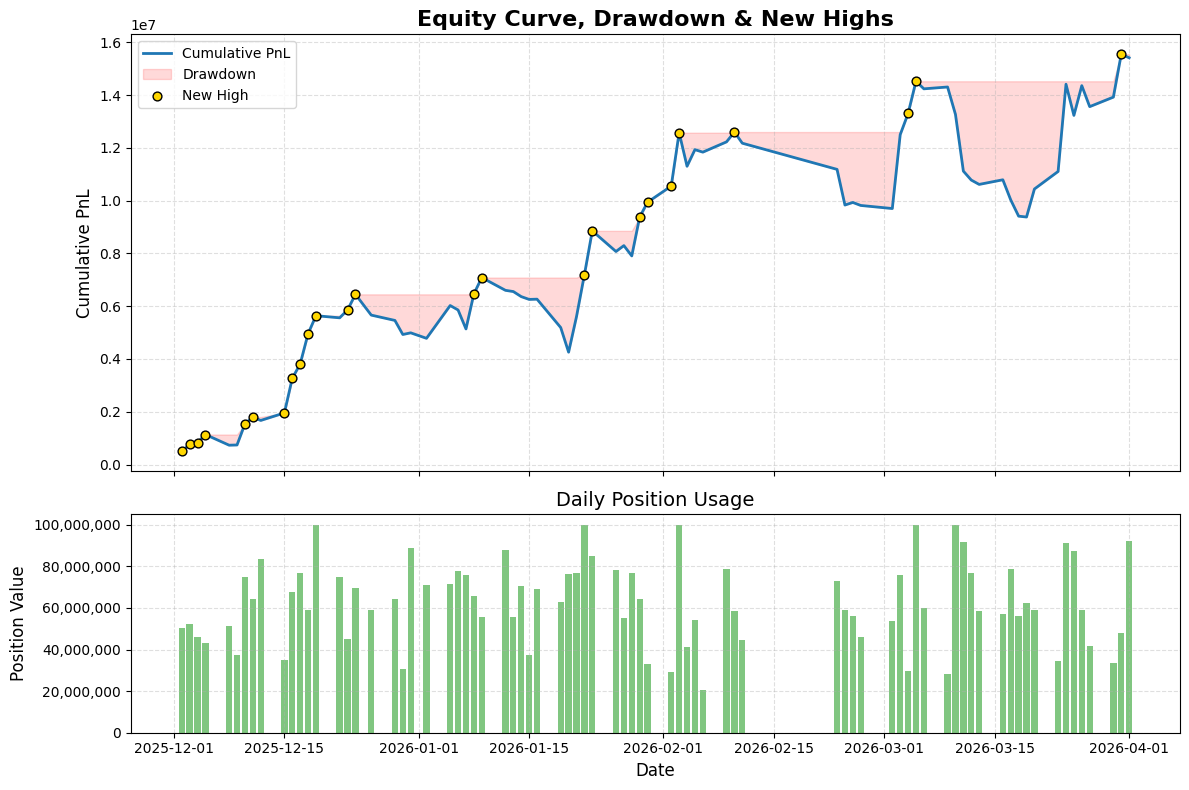


指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 1,541.27
近一年報酬（萬）      : 1,541.27
風報比                  : 3.00
年化 Sharpe          : 3.42
創高最長費時 (天)     : 17
平均每日交易商品數   : 50.26

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 76.19%
近一年報酬率（近一年平均部位）: 24.44%
勝率 (日/單筆)      : 54.55% / 57.35%
平均BP (單/單位)   : 38.43 / 31.7466

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -214.88 萬
MDD金額/佔平均比   : -514.44 萬 / 8.16%
平均/最大部位(萬)  : 6,305.10 / 9,998.07
平均最大單一商品比  : 3.57%



In [129]:
bt = BackTest(signalwithRisk_df[signalwithRisk_df.Date.astype(int) > 20251201])
results = bt.run_analysis()


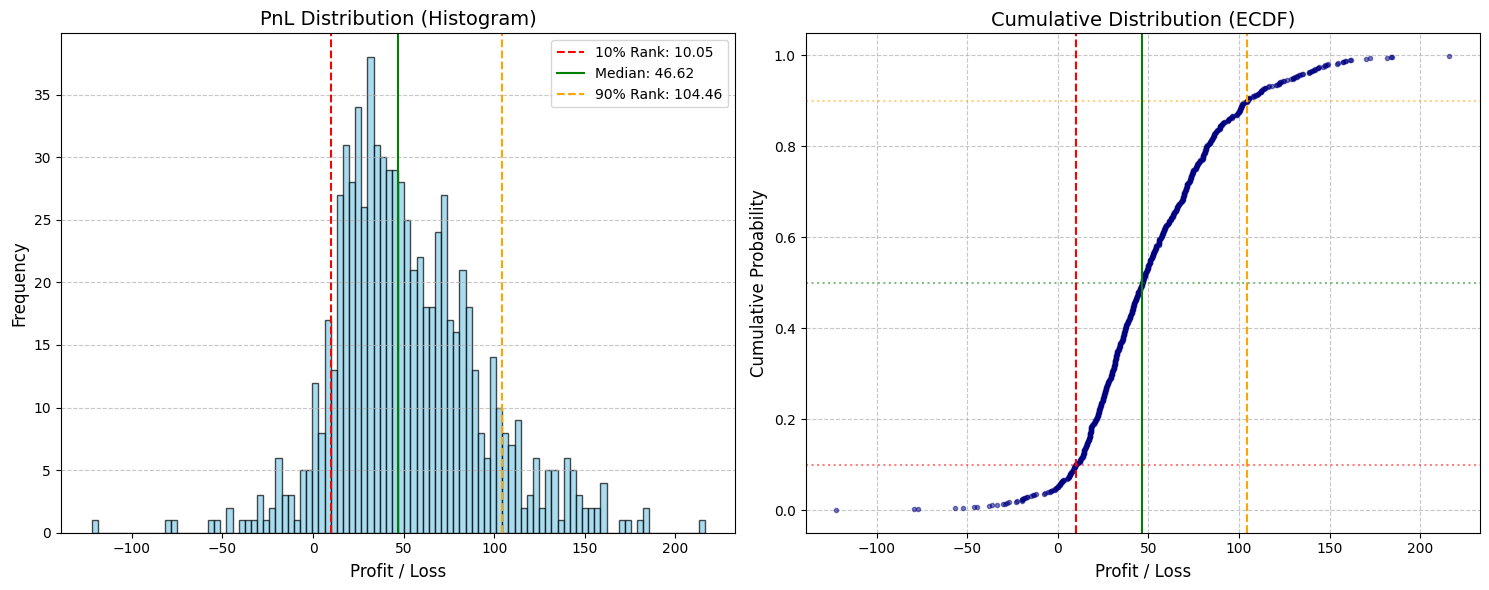

In [64]:

# 1. 計算分位數數值
q10 = series1.quantile(0.1)
q50 = series1.quantile(0.5)
q90 = series1.quantile(0.9)

# 2. 排序數據以計算累積機率 (ECDF)
sorted_data = np.sort(series1)
y_values = np.arange(len(sorted_data)) / float(len(sorted_data))

# 建立畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 圖左：直方圖 (棒狀圖) ---
axes[0].hist(series1, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
# 加入垂直分界線
axes[0].axvline(q10, color='red', linestyle='--', linewidth=1.5, label=f'10% Rank: {q10:.2f}')
axes[0].axvline(q50, color='green', linestyle='-', linewidth=1.5, label=f'Median: {q50:.2f}')
axes[0].axvline(q90, color='orange', linestyle='--', linewidth=1.5, label=f'90% Rank: {q90:.2f}')

axes[0].set_title('PnL Distribution (Histogram)', fontsize=14)
axes[0].set_xlabel('Profit / Loss', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend() # 顯示圖例
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- 圖右：累積圖 (ECDF) ---
axes[1].plot(sorted_data, y_values, marker='.', linestyle='none', color='navy', alpha=0.5)
# 加入垂直分界線 (X軸：損益數值)
axes[1].axvline(q10, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(q50, color='green', linestyle='-', linewidth=1.5)
axes[1].axvline(q90, color='orange', linestyle='--', linewidth=1.5)
# 加入水平參考線 (Y軸：排名百分比)
axes[1].axhline(0.1, color='red', linestyle=':', alpha=0.5)
axes[1].axhline(0.5, color='green', linestyle=':', alpha=0.5)
axes[1].axhline(0.9, color='orange', linestyle=':', alpha=0.5)

axes[1].set_title('Cumulative Distribution (ECDF)', fontsize=14)
axes[1].set_xlabel('Profit / Loss', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [34]:
# 計算所有天數的排名比例
series1 = ( signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP - 19.3) / 10000 / 10).groupby(signalwithRisk_df.Date).sum()


In [35]:
date_portfolio = series1.reset_index().rename(columns={0: 'PL'})
date_portfolio['Position'] = ( signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum().reset_index(drop=True)
date_portfolio['Return'] = date_portfolio['PL'] / date_portfolio['Position'] * 100

In [36]:
date_portfolio.describe()

,PL,Position,Return
count,775.000000,775.000000,775.000000
mean,58.830490,9027.584786,0.581075
std,103.256129,2643.672999,1.027071
min,-525.261782,938.870000,-4.173484
25%,-7.949730,7146.297500,-0.092956
50%,43.067597,8983.910000,0.530814
75%,112.909177,10906.365000,1.221900
max,535.075835,14999.250000,4.249645


In [37]:

from pathlib import Path
import os
PROJECT_ROOT = Path(os.path.abspath('')).parents[2]


dateData = []
for d in tqdm( date_portfolio.Date[:-1] ) : 
    # 讀取 marketData
    maket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/marketData/{d}_marketData.parquet')
    
    # 讀取 preMarketData (對應日期的每日特徵)
    premarket_df = pd.read_parquet(f'{PROJECT_ROOT}/data/preMarket/{d}_preMarketData.parquet')
    
    # 確保 key 都是字串型態以防合併錯誤
    maket_df['quote_code'] = maket_df['quote_code'].astype(str)
    premarket_df['QuoteCode'] = premarket_df['QuoteCode'].astype(str)
    
    # 合併兩個 DataFrame
    merged_df = pd.merge(
        maket_df, 
        premarket_df, 
        left_on='quote_code', 
        right_on='QuoteCode', 
        how='inner'
    )
    
    # 計算 toOpen
    merged_df['toOpen'] = (merged_df['open_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']
    merged_df['Return'] = (merged_df['close_price'] - merged_df['opening_ref_price']) / merged_df['opening_ref_price']

    tsmc = merged_df[merged_df['quote_code'] == '2330']
    tsmcOpen = tsmc.toOpen.iloc[0]
    tsmcReturn = tsmc.Return.iloc[0]
    # 2. day_amount_rank < 100 的 mean
    top_df = merged_df[merged_df['day_amount_rank'] < 100]
    topOpen = top_df.toOpen.mean(numeric_only=True)
    topDrop = top_df.toOpen.apply(np.sign).mean(numeric_only=True)
    topReturn = top_df.Return.mean(numeric_only=True)
    
    dateData.append( [tsmcOpen, tsmcReturn, topOpen, topDrop, topReturn])
    # break


100%|██████████| 774/774 [00:19<00:00, 39.39it/s]


In [38]:
date_portfolio = pd.concat( [date_portfolio, pd.DataFrame(columns=['tsmOpen', 'tsmReturn', 'topOpen', 'topDrop', 'topReturn'], data = dateData) ], axis = 1)

In [39]:
date_portfolio= date_portfolio.reset_index(drop=True)

In [40]:
date_portfolio['topStd_10D'] = (date_portfolio.topDrop).rolling(10,min_periods=1).std().shift()
date_portfolio['topReturnlast_10D'] = (date_portfolio.topReturn).rolling(10,min_periods=1).std().shift()

In [41]:
date_portfolio['Count'] =  (date_portfolio.topOpen < 0.002) | (date_portfolio.topReturnlast_10D > 0.015) 
# date_portfolio['Count'] =  (date_portfolio.topOpen < 0.00) | (date_portfolio.topReturnlast_10D < -0.025) 

In [42]:
date_portfolio['Count'].mean()

np.float64(0.4425806451612903)

<Axes: >

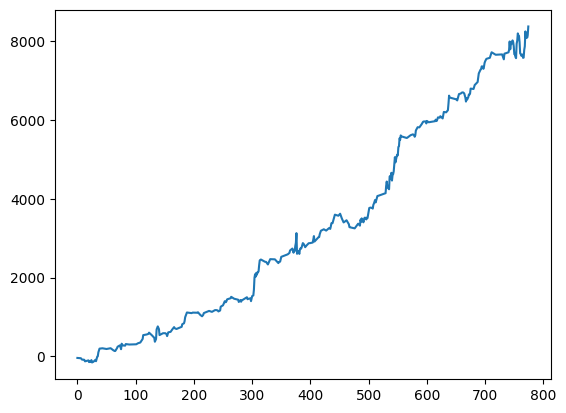

In [43]:
date_portfolio[ (date_portfolio.Count == 1) ].PL.cumsum().plot()
# date_portfolio[ (date_portfolio.topReturnlast_10D.rolling(window=100,min_periods=1).rank(ascending=True, pct=True) )<0.05 ].PL.cumsum().plot()

<Axes: >

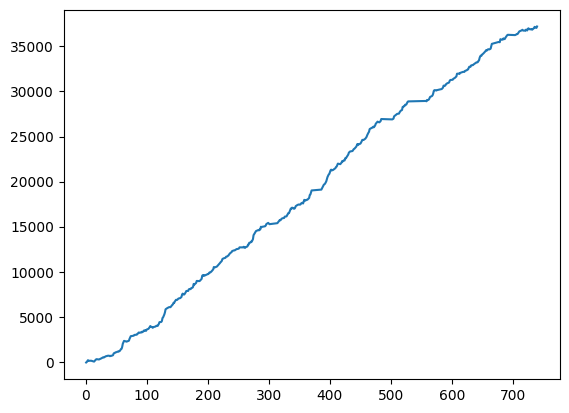

In [44]:
date_portfolio[ date_portfolio.Count == 0 ].PL.cumsum().plot()

In [45]:
abonraml_DATE = date_portfolio[ (date_portfolio.Count ==1) ].Date.to_list()

In [46]:
abonraml_DATE

['20230106',
 '20230117',
 '20230131',
 '20230203',
 '20230206',
 '20230207',
 '20230209',
 '20230215',
 '20230216',
 '20230217',
 '20230221',
 '20230222',
 '20230223',
 '20230301',
 '20230302',
 '20230307',
 '20230308',
 '20230310',
 '20230313',
 '20230314',
 '20230316',
 '20230323',
 '20230406',
 '20230417',
 '20230424',
 '20230426',
 '20230427',
 '20230503',
 '20230504',
 '20230510',
 '20230512',
 '20230515',
 '20230517',
 '20230523',
 '20230524',
 '20230601',
 '20230619',
 '20230626',
 '20230630',
 '20230706',
 '20230707',
 '20230717',
 '20230720',
 '20230721',
 '20230728',
 '20230804',
 '20230807',
 '20230809',
 '20230810',
 '20230814',
 '20230816',
 '20230817',
 '20230825',
 '20230831',
 '20230904',
 '20230905',
 '20230907',
 '20230913',
 '20230918',
 '20230921',
 '20230922',
 '20230927',
 '20231004',
 '20231013',
 '20231016',
 '20231019',
 '20231020',
 '20231023',
 '20231026',
 '20231107',
 '20231109',
 '20231120',
 '20231122',
 '20231128',
 '20231201',
 '20231205',
 '20231206',

In [47]:
import json

# 假設這是你的異常日期清單 (字串格式)

# 將 list 存成 JSON 檔案
with open('abnormal_dates.json', 'w') as f:
    json.dump(abonraml_DATE, f)
    
print("異常日期清單已儲存！")

異常日期清單已儲存！


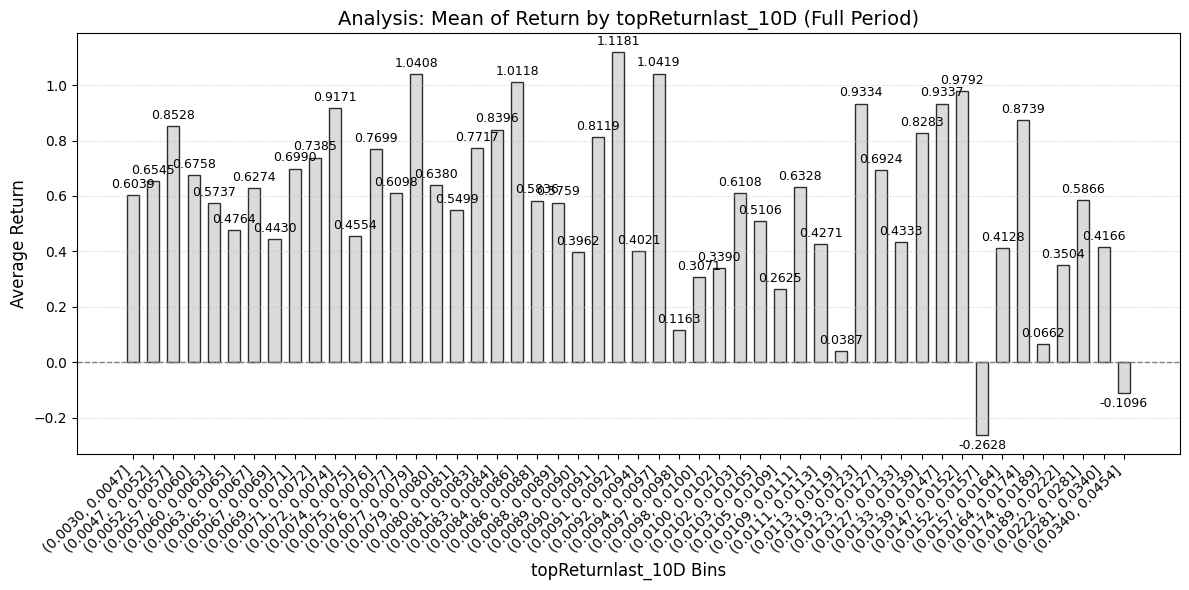

In [48]:
# plot_qcut_analysis(date_portfolio, col_a='topOpen', col_b=f'Return', q=50 , isMin=False)
plot_qcut_analysis(date_portfolio, col_a='topReturnlast_10D', col_b=f'Return', q=50 , isMin=False)

In [49]:
condition = date_portfolio.test > -0.005
print(condition.sum())
date_portfolio[ condition ].PL.cumsum().plot()

AttributeError: 'DataFrame' object has no attribute 'test'